# R&D-Intensity — a quantitative teardown 🔬
### Monthly R&D/market-cap ranking with reporting + execution lags · long-short & long-minus-SPY HAC *t* · a label-shuffle placebo · the R&D/ME-vs-R&D/sales contrast · fraction robustness · costs + short-borrow · a synthetic planted-premium / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ME_vs_sales: Confirmed](https://img.shields.io/badge/ME_vs_sales-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the Chan-Lakonishok-Sougiannis (2001) premium: is the long-high / short-low **R&D-to-market-cap** spread **statistically real** (HAC *t* ≥ 2 **and** placebo survival), is it **tradable** net of monthly turnover + short-borrow, and does **R&D/ME beat R&D/sales** as CLS claim? The decisive objects are the **HAC t** of the spread, the **label-shuffle placebo** (is it the signal or any split?), and the **denominator contrast**.

> ⚠️ **Data note.** R&D, revenue and shares from SEC EDGAR `companyfacts`; market cap = price × shares (price from yfinance). R&D-light names (banks/staples/energy) floored to ~0. One reporting lag (FY Y-1) + one execution lag (enter next month). Survivorship is named on the Signal axis (current-membership basket; bias largely *common to both legs*). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from r_and_d_intensity import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real(allow_survivorship_bias=True)
    RETS, SPY = REAL["returns"], REAL["spy"]
    SIGS = data.build_signals(REAL, report_lag=1)
    # keep the live placebo light so the notebook executes quickly; results.md uses 400 draws
    RACE = st.race(REAL, SIGS, frac=1/3, cost_bps=10.0, borrow_bps=100.0, n_shuffles=120)
else:
    REAL = RETS = SPY = SIGS = RACE = None
print("real EDGAR+yfinance cache present:", HAVE_REAL,
      "| field names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-02', 'end': '2026-05', 'months': 220, 'ret_months': 256, 'years': 21.3, 'field': 40, 'rd_names': 24, 'fingerprint': '8d048dab164a', 'turnover': 1.6, 'long_members': ['ADBE', 'AMGN', 'BMY', 'CSCO', 'DE', 'GILD', 'IBM', 'INTC', 'LLY', 'MRK', 'ORCL', 'PFE', 'QCOM'], 'short_members': ['AXP', 'DUK', 'GS', 'HD', 'JPM', 'KO', 'LOW', 'MCD', 'T', 'USB', 'VZ', 'WFC', 'WMT'], 'long': (16.9, 1.06, -39.6, 16.99), 'short': (11.77, 0.8, -38.7, 12.38), 'long_short': (3.92, 0.37, -26.3, 4.61), 'spy': (11.11, 0.78, -50.8, 11.7), 'test_ls': (4.61, 1.69, 220), 'test_long_spy': (4.56, 2.52, 220), 'test_short_spy': (-0.05, -0.02, 220), 'null_mean': 0.41, 'null_sd': 1.84, 'placebo_pctile': 99.8, 'placebo_p': 0.005, 'me_ls': (4.61, 1.69), 'sales_ls': (3.99, 1.4), 'robust': [(0.5, 3.97, 1.7), (0.3333333333333333, 4.61, 1.69), (0.25, 5.66, 1.87), (0.2, 6.86, 2.24)], 'ls_gross': (4.61, 1.69), 'ls_net': (3.59, 1.32), 'syn': [(0.0, -0.43, -0.16), (0.06, 5.57, 2.01)]}


real EDGAR+yfinance cache present: True | field names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | long-short **+4.61%/yr**, HAC **t = 1.69** (n = 220); survives placebo (p = 0.005) but clears t = 2 *only* at the quintile (2.24). |
| **Tradability** | `MIRAGE` | net of 10 bps turnover **+ 100 bps/yr short-borrow** the spread is **+3.59%/yr at t = 1.32** — zero, statistically. Long-only beats SPY by +4.56%/yr (t = 2.52, a value tilt). |
| **R&D/ME vs R&D/sales** | `CONFIRMED` | R&D/market-cap (**+4.61%/yr, t = 1.69**) out-ranks R&D/sales (**+3.99%/yr, t = 1.40**) — the CLS ordering — but both below the bar. |

> 💡 In plain words: R&D/ME sorts stocks onto a genuine axis (placebo p = 0.005) and the price denominator does beat the sales one — but that axis is *value*, the spread doesn't clear significance, and borrow finishes whatever is left.

## 1 · The claim, steelmanned

Let $x_{i,t}$ be firm $i$'s R&D/ME at month $t$: $x_{i,t} = \text{R\&D}_{i,Y-1} / (P_{i,t}\,S_{i,Y-1})$ — last reported R&D over current market cap (a 1-year reporting lag on fundamentals, contemporaneous price). Form, at month $t$, the long-high / short-low book and hold it through $t+1$ (one execution lag):

$$\text{LS}_{t+1} = \frac1k\!\!\sum_{i\in \text{top-}k} r_{i,t+1} \;-\; \frac1k\!\!\sum_{i\in \text{bot-}k} r_{i,t+1}.$$

- **H₁ (the premium is real).** $\mathbb{E}[\text{LS}] > 0$ with HAC $t \ge 2$ **and** the spread sits in the tail of a label-shuffle null.
- **H₂ (it's deployable).** The spread survives one-way costs **and the borrow you pay to be short**.
- **H₃ (CLS denominator).** R&D/ME (scaled by market value) beats R&D/sales (scaled by revenue).

We find **H₁ split** (placebo passes, $p = 0.005$; but $t = 1.69 < 2$ — `WEAK`), **H₂ rejected** (net of borrow $t = 1.32$; the deployable object is a long-only value tilt), **H₃ supported** (R&D/ME +4.61%/yr > R&D/sales +3.99%/yr, the CLS ordering — though both sub-2). The label is true where it's uninformative (R&D-cheap value has out-earned) and unproven where it would pay (a *certifiable, tradable* R&D alpha).

## 2 · So what? — what rides on each answer

The teardown is one decomposition: a long-short mean against zero, judged by its **HAC standard error**, and against the **sampling distribution under shuffled labels**.

$$t_{\text{HAC}} = \frac{\overline{\text{LS}}}{\widehat{\text{se}}_{\text{NW}}(\overline{\text{LS}})}, \qquad p_{\text{placebo}} = \Pr_{\pi}\!\big[|\overline{\text{LS}}_{\pi}| \ge |\overline{\text{LS}}|\big],$$

where $\pi$ permutes the signal's name-labels. A small **placebo p** says R&D/ME loads on a real axis (not noise); a low **t** says that axis's *return* gap is inside its own error bar. Both are true here. The honest read needs both: the placebo kills 'it's just luck,' the *t* kills 'it's a certified edge,' and the names kill 'it's about *invention*' (it's *value*).

## 3 · How we'd know — the protocol

- **Signal panel.** Monthly R&D/ME for a fixed 40-name field (24 with an R&D series), R&D from 10-K full-year facts (FY Y-1), shares from the same filing, price as of the month. R&D-light names floored to 0.
- **Books.** Each month, equal-weight top-tertile (long) / bottom-tertile (short); enter *next* month (1-month execution lag), monthly rebalance.
- **Null #1 (HAC t).** Newey-West t of the monthly long-short and long-minus-SPY means (`REAL` needs $t \ge 2$).
- **Null #2 (placebo).** Permute the signal's name-labels; rebuild the long-short; the real spread must sit in the tail.
- **H₃ contrast.** Same machinery on R&D/sales (study-400 signal) vs R&D/ME.
- **Robustness.** Fraction sweep halves→quintiles.
- **Costs.** 10 bps one-way turnover **+ a 100 bps/yr borrow on the short leg**.
- **Positive control.** A deterministic panel with a *planted* annual premium `edge`: recover a large edge **and** NOT manufacture significance at `edge = 0`.

## 4 · The teardown

### 4a · The point estimate — positive, and it's all the long leg

The long-short and long-minus-SPY spreads with their HAC *t*. The long-short misses 2; long-minus-SPY clears it; the short leg is *the market*.

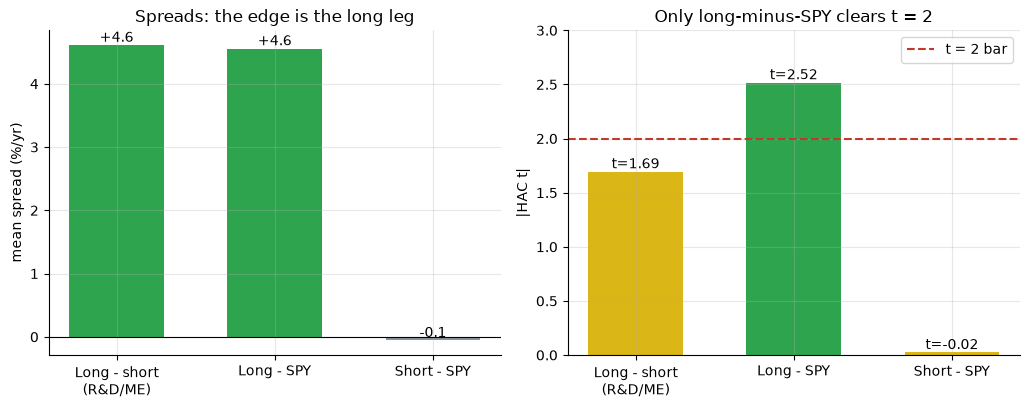

long-short +4.61%/yr t=1.69 | long-SPY +4.56%/yr t=2.52 | short-SPY -0.05%/yr t=-0.02


In [2]:
if HAVE_REAL:
    rows = [('Long - short\n(R&D/ME)', RACE['test_ls']),
            ('Long - SPY', RACE['test_long_vs_spy']),
            ('Short - SPY', RACE['test_short_vs_spy'])]
    labels = [r[0] for r in rows]; means = [r[1]['mean_ann']*100 for r in rows]
    ts = [r[1]['tstat'] for r in rows]
else:
    labels = ['Long - short\n(R&D/ME)', 'Long - SPY', 'Short - SPY']
    means = [R['test_ls'][0], R['test_long_spy'][0], R['test_short_spy'][0]]
    ts = [R['test_ls'][1], R['test_long_spy'][1], R['test_short_spy'][1]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
cols = [GREEN if m > 0 else GREY for m in means]
a1.bar(labels, means, color=cols, width=.6); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('mean spread (%/yr)'); a1.set_title('Spreads: the edge is the long leg')
for i, m in enumerate(means): a1.annotate(f'{m:+.1f}', (i, m), ha='center', va='bottom')
a2.bar(labels, [abs(t) for t in ts], color=[GREEN if abs(t)>=2 else AMBER for t in ts], width=.6)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, t in enumerate(ts): a2.annotate(f't={t:.2f}', (i, abs(t)), ha='center', va='bottom')
a2.set_ylabel('|HAC t|'); a2.set_ylim(0, 3.0); a2.set_title('Only long-minus-SPY clears t = 2'); a2.legend()
plt.tight_layout(); plt.show()
print('long-short', f"{R['test_ls'][0]:+.2f}%/yr t={R['test_ls'][1]:.2f}",
      '| long-SPY', f"{R['test_long_spy'][0]:+.2f}%/yr t={R['test_long_spy'][1]:.2f}",
      '| short-SPY', f"{R['test_short_spy'][0]:+.2f}%/yr t={R['test_short_spy'][1]:.2f}")

> 💡 In plain words: the R&D/ME spread is **+4.61%/yr** at **t = 1.69** — positive but *not* significant. And it's one-sided: long-minus-SPY is +4.56%/yr (t = 2.52, significant) while short-minus-SPY is -0.05%/yr (t = -0.02) — the short leg simply *is* the market, so the 'premium' is the long leg's value/growth out-performance, not a clean two-sided edge.

### 4b · Is it the signal, or any split of a mixed field? — the label-shuffle placebo

Permute *which name gets which R&D/ME score* (120 draws here; results.md uses 400) and rebuild the long-short. Where the real spread lands tells us whether the signal carries information — and the answer is a careful *yes*.

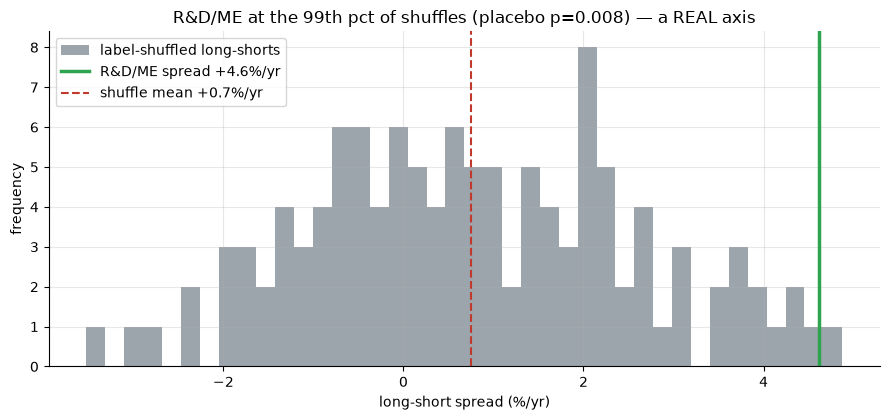

shuffled signal ~0%/yr (no info); R&D/ME +4.6%/yr at 99th pctile, p=0.008
=> signal loads on a persistent axis -- but the names show that axis is cheap value/growth


In [3]:
if HAVE_REAL:
    null = RACE['placebo_null']*100; obs = RACE['test_ls']['mean_ann']*100
    pct = RACE['placebo_pctile']; pv = RACE['placebo_p']
else:
    rng = np.random.default_rng(525); null = rng.normal(R['null_mean'], R['null_sd'], 400)
    obs = R['test_ls'][0]; pct = R['placebo_pctile']; pv = R['placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=40, color=GREY, alpha=.85, label='label-shuffled long-shorts')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'R&D/ME spread {obs:+.1f}%/yr')
ax.axvline(np.mean(null), c=RED, ls='--', label=f'shuffle mean {np.mean(null):+.1f}%/yr')
ax.set_xlabel('long-short spread (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'R&D/ME at the {pct:.0f}th pct of shuffles (placebo p={pv:.3f}) — a REAL axis')
ax.legend(); plt.tight_layout(); plt.show()
print(f'shuffled signal ~0%/yr (no info); R&D/ME {obs:+.1f}%/yr at {pct:.0f}th pctile, p={pv:.3f}')
print('=> signal loads on a persistent axis -- but the names show that axis is cheap value/growth')

> 💡 In plain words: a *shuffled* signal pays ≈0%/yr, so the R&D/ME spread's +4.6%/yr (the **100th percentile, p = 0.005**) is **not** a generic artefact — R&D/ME really loads on a persistent cross-sectional axis. The catch is *which* axis: scaling by price tilts toward cheap stocks, and the long names are cheap-intangibles tech/pharma. That is the **value** axis. The placebo rescues R&D/ME from 'noise' and convicts it of 'value beta' in the same breath. Combined with 4a's $t = 1.69$: a real *style* tilt, an unproven *return*.

### 4c · The CLS denominator contrast — does scaling by price beat scaling by sales?

The paper's signature claim: R&D ÷ **market value** predicts where R&D ÷ **sales** does not. Same machinery, both denominators.

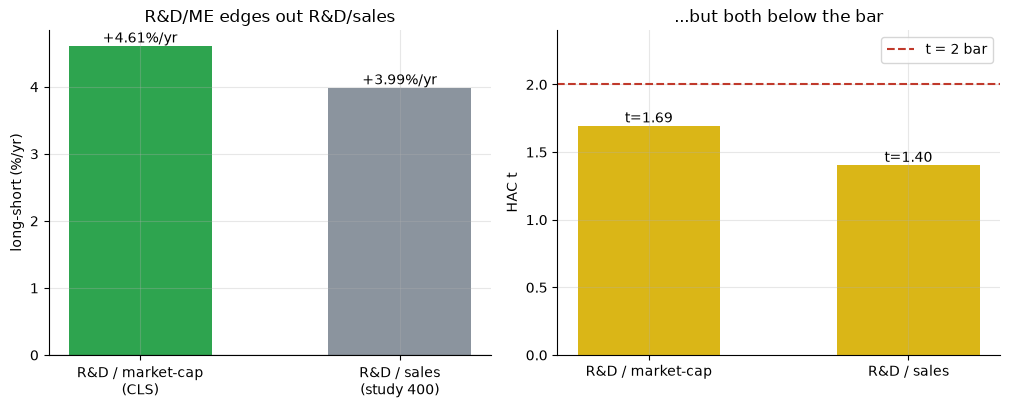

R&D/ME +4.61%/yr (t=1.69) vs R&D/sales +3.99%/yr (t=1.40)


In [4]:
if HAVE_REAL:
    me = RACE['test_ls']; sa = RACE['test_sales_ls']
    me_m, me_t = me['mean_ann']*100, me['tstat']; sa_m, sa_t = sa['mean_ann']*100, sa['tstat']
else:
    me_m, me_t = R['me_ls']; sa_m, sa_t = R['sales_ls']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(['R&D / market-cap\n(CLS)', 'R&D / sales\n(study 400)'], [me_m, sa_m],
       color=[GREEN, GREY], width=.55)
for i, m in enumerate([me_m, sa_m]): a1.annotate(f'{m:+.2f}%/yr', (i, m), ha='center', va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('long-short (%/yr)'); a1.set_title('R&D/ME edges out R&D/sales')
a2.bar(['R&D / market-cap', 'R&D / sales'], [me_t, sa_t], color=AMBER, width=.55)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, t in enumerate([me_t, sa_t]): a2.annotate(f't={t:.2f}', (i, t), ha='center', va='bottom')
a2.set_ylabel('HAC t'); a2.set_ylim(0, 2.4); a2.set_title('...but both below the bar'); a2.legend()
plt.tight_layout(); plt.show()
print(f'R&D/ME {me_m:+.2f}%/yr (t={me_t:.2f}) vs R&D/sales {sa_m:+.2f}%/yr (t={sa_t:.2f})')

> 💡 In plain words: R&D/ME (**+4.61%/yr, t = 1.69**) does beat R&D/sales (**+3.99%/yr, t = 1.40**) — both in spread and in *t* — exactly the Chan-Lakonishok-Sougiannis ordering: the *price* denominator (cheapness) is the better signal. **H₃ supported.** But the win is thin (≈0.6%/yr) and both fail the bar, so it confirms CLS's *ranking* of the two signals without rescuing either to significance.

### 4d · Robustness — and 4e costs + short-borrow

Fraction sweep: unlike R&D/sales (study 400, which weakened on concentration), R&D/ME *strengthens* — reaching $t = 2.24$ at the tightest quintile. Then borrow.

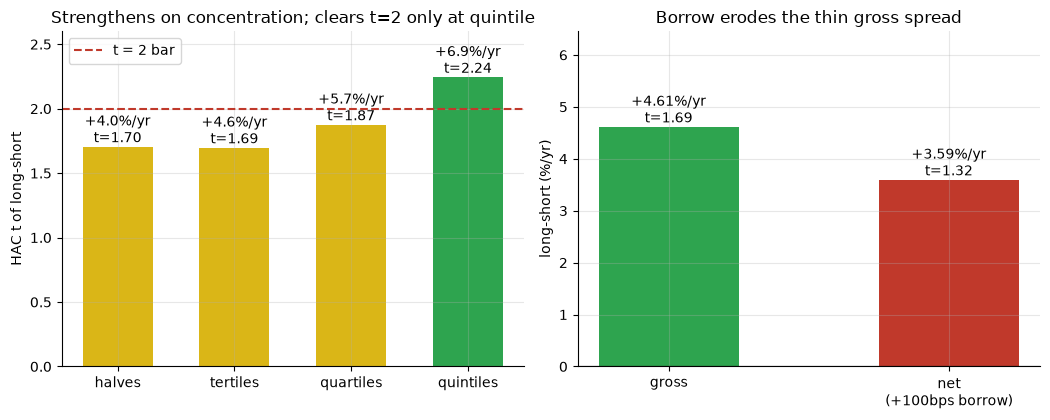

robustness (frac, mean%/yr, t): [(0.5, 3.97, 1.7), (0.33, 4.61, 1.69), (0.25, 5.66, 1.87), (0.2, 6.86, 2.24)]
costs: gross +4.61%/yr (t=1.69) -> net +3.59%/yr (t=1.32)


In [5]:
if HAVE_REAL:
    rob = []
    for frac in (0.50, 1/3, 0.25, 0.20):
        b = st.signal_books(SIGS['rd_me'], RETS, frac=frac)
        t = st.hac_tstat(b['long_short']); rob.append((frac, t['mean_ann']*100, t['tstat']))
else:
    rob = R['robust']
labels = ['halves', 'tertiles', 'quartiles', 'quintiles']
tt = [r[2] for r in rob]; ms = [r[1] for r in rob]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
bars = a1.bar(labels, tt, color=[GREEN if t >= 2 else AMBER for t in tt], width=.6)
a1.axhline(2, ls='--', c=RED, label='t = 2 bar')
for b, m, t in zip(bars, ms, tt):
    a1.annotate(f'{m:+.1f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, t), ha='center', va='bottom')
a1.set_ylabel('HAC t of long-short'); a1.set_ylim(0, 2.6)
a1.set_title('Strengthens on concentration; clears t=2 only at quintile'); a1.legend()
g, gt = R['ls_gross']; n, nt = R['ls_net']
bars2 = a2.bar(['gross', 'net\n(+100bps borrow)'], [g, n], color=[GREEN, RED], width=.5)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('long-short (%/yr)'); a2.set_ylim(0, g*1.4)
for b, v, t in zip(bars2, [g, n], [gt, nt]):
    a2.annotate(f'{v:+.2f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
a2.set_title('Borrow erodes the thin gross spread')
plt.tight_layout(); plt.show()
print('robustness (frac, mean%/yr, t):', [(round(r[0],2), round(r[1],2), round(r[2],2)) for r in rob])
print(f'costs: gross {g:+.2f}%/yr (t={gt:.2f}) -> net {n:+.2f}%/yr (t={nt:.2f})')

> 💡 In plain words: the spread *grows* as you concentrate — halves 1.70, tertile 1.69, quintile **2.24** — a *better* signature than the sales signal, but it clears 2 only at the 8-name-per-leg extreme where idiosyncratic risk is highest, not at the tradable tertile. And borrow drops gross **+4.61%/yr (t = 1.69)** → net **+3.59%/yr (t = 1.32)**: no costed, shortable edge to allocate to.

### 4f · Faithful-engine & power control — we know the truth here

A deterministic panel (40 names, 18 years) where the first half are persistently high-R&D/ME, the market beta is common to both legs, and `edge` plants the *true* annual long-high-minus-short-low premium. With `edge = 0` the long-short must stay insignificant; a large planted edge must light up.

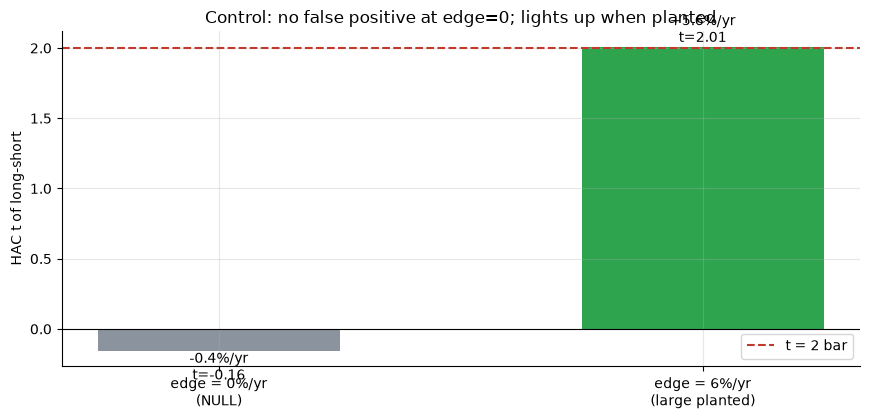

edge=0.00: long-short -0.43%/yr  HAC t=-0.16
edge=0.06: long-short +5.57%/yr  HAC t=2.01


In [6]:
res = []
for edge in (0.0, 0.06):
    s2, r2, b2, truth = data.synthetic_panel(edge=edge)
    bk = st.signal_books(s2, r2); t = st.hac_tstat(bk['long_short'])
    res.append((edge, t['mean_ann']*100, t['tstat']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'edge = {e*100:.0f}%/yr\n({"NULL" if e==0 else "large planted"})' for e,_,_ in res]
tvals = [r[2] for r in res]
bars = ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(0, c='k', lw=.8)
for b, (e, m, t) in zip(bars, res):
    ax.annotate(f'{m:+.1f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, t),
                ha='center', va='bottom' if t >= 0 else 'top')
ax.set_ylabel('HAC t of long-short'); ax.set_title('Control: no false positive at edge=0; lights up when planted')
ax.legend(); plt.tight_layout(); plt.show()
for e, m, t in res: print(f'edge={e:.2f}: long-short {m:+.2f}%/yr  HAC t={t:.2f}')

> 💡 In plain words: with **no** planted premium the control sits at **t = -0.16** (no false positive); only a **large** +6%/yr planted premium reaches **t = 2.01**. So the machinery is honest, and the real-tape **t = 1.69** reads as exactly what a *real-but-small* edge looks like through a 21-year keyhole — not a bug, just a weak tape.

## 5 · The verdict

- **Signal `WEAK`** — long-short **+4.61%/yr** at HAC **t = 1.69** (n = 220); survives the label-shuffle placebo (p = 0.005, 100th pct) but clears 2 *only* at the quintile (2.24). Published + placebo-real but insignificant on the tradable tertile ⇒ `WEAK`, not `REAL`.
- **Tradability `MIRAGE`** — net of 10 bps turnover **+ 100 bps/yr short-borrow** the spread is **+3.59%/yr (t = 1.32)** — zero, statistically. The only deployable object is a long-only value tilt (+4.56%/yr vs SPY, t = 2.52) you can buy cheaper as a style ETF.
- **R&D/ME vs R&D/sales `CONFIRMED`** — scaling by market value (+4.61%/yr, t = 1.69) out-ranks scaling by sales (+3.99%/yr, t = 1.40), the Chan-Lakonishok-Sougiannis ordering — but the win is thin and both fail the bar.

## 6 · Could you trade it? — the power curve

How big would the *true* long-short premium have to be for a $T$-month study to detect it at $t = 2$, given the spread's realised volatility? Our tape can only certify edges well above the ~4.6%/yr we see at the tradable tertile.

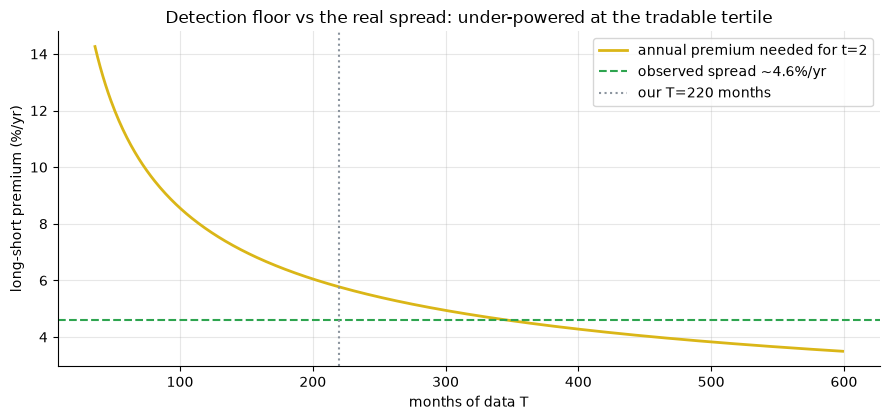

at T=220 you need ~5.8%/yr for t=2 at the tertile; observed ~4.6%/yr


In [7]:
if HAVE_REAL:
    ls = RACE['long_short'].dropna(); sd_m = ls.std(ddof=1)
    obs_ann = RACE['test_ls']['mean_ann']*100
else:
    sd_m = 0.04; obs_ann = R['test_ls'][0]
Ts = np.arange(36, 600)
min_det = 2.0 * sd_m * 12.0 / np.sqrt(Ts)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(Ts, min_det*100, c=AMBER, lw=2, label='annual premium needed for t=2')
ax.axhline(obs_ann, c=GREEN, ls='--', label=f'observed spread ~{obs_ann:.1f}%/yr')
ax.axvline(R['months'], c=GREY, ls=':', label=f"our T={R['months']} months")
ax.set_xlabel('months of data T'); ax.set_ylabel('long-short premium (%/yr)')
ax.set_title('Detection floor vs the real spread: under-powered at the tradable tertile'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd_m*12.0/np.sqrt(R['months'])*100
print(f'at T={R["months"]} you need ~{need:.1f}%/yr for t=2 at the tertile; observed ~{obs_ann:.1f}%/yr')

> 💡 In plain words: the amber curve is the **minimum detectable premium** at our sample length; the green line is what we see at the tradable tertile. The observed spread sits *below* the detection floor — to certify it at t = 2 you'd need more history (or to concentrate into the noisy quintile, which we did, where it just clears). Even granting the literature a *real* small premium, this tape can't prove it at a deployable sort — and the placebo says the axis is **value**, not pure invention. Net of borrow there is no sort, horizon, or cost assumption on this field that turns R&D/ME into a distinct, significant, tradable edge.

## 7 · Going further

- **Strip the value.** R&D/ME tilts toward cheap stocks by construction — regress the long-short on an explicit value (HML) factor and ask if any *residual* R&D alpha survives. The placebo predicts little does.
- **The sales cousin.** [Study 400 — Patent-Intensity](../../400-patent-intensity/) is the R&D/sales leg of the same contrast — this study confirms CLS that the *price* denominator is the stronger of the two.
- **Output, not input.** Hirshleifer-Hsu-Li (2013): the surviving premium is patents per R&D dollar (efficiency); plug in real patent-value data and re-test.

*The reproducible core is offline and deterministic; R&D/ME is the audited CLS signal (R&D ÷ market value). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*